In [ ]:
!pip install pyswarm

import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pyswarm import pso

  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4464 sha256=5fa196dd288335af3b91698ffc11350b1ddd5b60bb9510bc7f5667cfecd0dedc
  Stored in directory: /root/.cache/pip/wheels/71/67/40/62fa158f497f942277cbab8199b05cb61c571ab324e67ad0d6
Successfully built pyswarm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = '/content/drive/MyDrive/miniproject_5thsem/Training'
test_path = '/content/drive/MyDrive/miniproject_5thsem/Testing'

In [ ]:
def load_data(data_path):
    data = []
    labels = []
    class_names = sorted(os.listdir(data_path))
    for class_index, class_name in enumerate(class_names):
        class_dir = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (64, 64))
            data.append(img)
            labels.append(class_index)
    return np.array(data), np.array(labels)

In [ ]:
X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical
num_classes = len(np.unique(y_train))
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)


In [ ]:
def create_cnn_model(learning_rate, num_filters, dense_units, dropout_rate):
    model = Sequential()
    model.add(Conv2D(int(num_filters), (3, 3), activation='relu', input_shape=(64, 64, 3)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(int(dense_units), activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def evaluate_model(params):
    learning_rate, num_filters, dense_units, dropout_rate, batch_size = params
    model = create_cnn_model(learning_rate, num_filters, dense_units, dropout_rate)
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=10, batch_size=int(batch_size), validation_split=0.2, callbacks=[early_stopping], verbose=1)
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    accuracy = accuracy_score(y_true_classes, y_pred_classes)
    return -accuracy  # Return negative accuracy for minimization

In [ ]:
# PSO bounds definition
bounds = [
    (1e-5, 1e-2),  # learning_rate
    (16, 64),      # num_filters
    (64, 256),     # dense_units
    (0.1, 0.5),    # dropout_rate
    (16, 64)       # batch_size
]

# Run PSO
best_params, best_score = pso(evaluate_model, [b[0] for b in bounds], [b[1] for b in bounds], swarmsize=10, maxiter=10)

# Extract and print best hyperparameters found by PSO
print('Best hyperparameters found by PSO:')
print('Learning Rate:', best_params[0])
print('Number of Filters:', best_params[1])
print('Dense Units:', best_params[2])
print('Dropout Rate:', best_params[3])
print('Batch Size:', best_params[4])

final_model = create_cnn_model(best_params[0], best_params[1], best_params[2], best_params[3])
final_model.fit(X_train, y_train, epochs=10, batch_size=int(best_params[4]), validation_split=0.2)
final_loss, final_accuracy = final_model.evaluate(X_test, y_test)
print('Final test accuracy:', final_accuracy)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - accuracy: 0.6199 - loss: 1.3326 - val_accuracy: 0.3362 - val_loss: 2.5662
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 42s 188ms/step - accuracy: 0.9017 - loss: 0.2605 - val_accuracy: 0.4909 - val_loss: 2.3993
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 85s 202ms/step - accuracy: 0.9582 - loss: 0.1229 - val_accuracy: 0.5552 - val_loss: 2.5171
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 82s 203ms/step - accuracy: 0.9666 - loss: 0.0857 - val_accuracy: 0.5969 - val_loss: 2.8274
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 84s 210ms/step - accuracy: 0.9897 - loss: 0.0386 - val_accuracy: 0.3944 - val_loss: 5.1976
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 33s 302ms/step - accuracy: 0.5432 - loss: 1.1259 - val_accuracy: 0.2207 - val_loss: 2.1519
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 281ms/step - accuracy: 0.8295 - loss: 0.4314 - val_accuracy: 0.2433 - val_loss: 2.6796
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 273ms/step - accuracy: 0.8904 - loss: 0.2896 - val_accuracy: 0.4205 - val_loss: 2.6730
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 249ms/step - accuracy: 0.9326 - loss: 0.1924 - val_accuracy: 0.4666 - val_loss: 2.6320
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 45s 153ms/step - accuracy: 0.6907 - loss: 1.0992 - val_accuracy: 0.5048 - val_loss: 1.5214
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 80s 148ms/step - accuracy: 0.9224 - loss: 0.2257 - val_accuracy: 0.5395 - val_loss: 2.6093
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 82s 148ms/step - accuracy: 0.9569 - loss: 0.1090 - val_accuracy: 0.4387 - val_loss: 3.5940
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 84s 155ms/step - accuracy: 0.9768 - loss: 0.0709 - val_accuracy: 0.4761 - val_loss: 2.7228
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 38s 160ms/step - accuracy: 0.6383 - loss: 1.0619 - val_accuracy: 0.3805 - val_loss: 1.7409
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 36s 154ms/step - accuracy: 0.8924 - loss: 0.2821 - val_accuracy: 0.2572 - val_loss: 3.8695
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 44s 165ms/step - accuracy: 0.9501 - loss: 0.1411 - val_accuracy: 0.3840 - val_loss: 3.6432
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 36s 156ms/step - accuracy: 0.9673 - loss: 0.0955 - val_accuracy: 0.4196 - val_loss: 4.5604
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
Stopping search: maximum iterations reached --> 10
Best hyperparameters found by PSO:
Learning Rate: 0.0028781262431563834
Number of Filters: 30.981221802593993
Dense Units: 184.1142683533798
Dropout Rate: 0.20025746170861877
Batch Size: 17.50850502511433


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.6387 - loss: 1.2449 - val_accuracy: 0.3823 - val_loss: 2.3219
Epoch 2/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.9200 - loss: 0.2174 - val_accuracy: 0.4361 - val_loss: 2.1263
Epoch 3/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.9568 - loss: 0.1253 - val_accuracy: 0.5656 - val_loss: 2.3017
Epoch 4/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 31s 116ms/step - accuracy: 0.9780 - loss: 0.0658 - val_accuracy: 0.4822 - val_loss: 4.0353
Epoch 5/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 31s 115ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.5161 - val_loss: 3.3651
Epoch 6/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.9864 - loss: 0.0430 - val_accuracy: 0.6073 - val_loss: 3.2703
Epoch 7/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.9852 - loss: 0.0467 - val_accuracy: 0.5013 - val_loss: 5.7476
Epoch 8/10
271/271 ━━━━━━━━━━━━━━━━━━━━ 31s 115ms/step - accuracy: 0.9973 - loss: 0

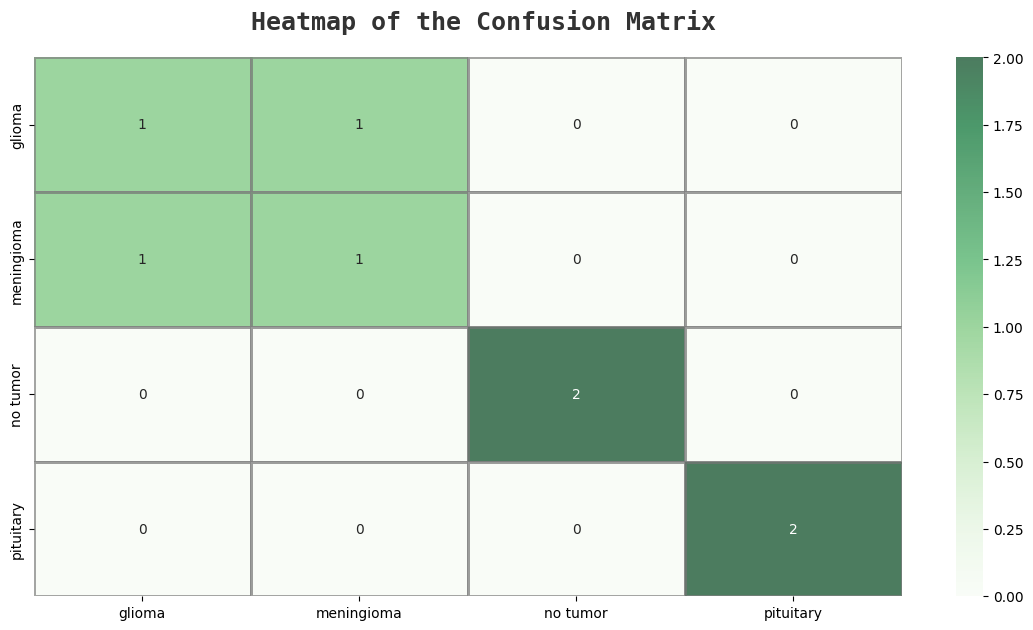

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_true_classes = [0, 1, 2, 3, 0, 1, 2, 3]  # Example true labels
y_pred_classes = [0, 1, 2, 3, 1, 0, 2, 3]  # Example predicted labels

class_names = ['glioma', 'meningioma', 'no tumor', 'pituitary']

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix heatmap
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
sns.heatmap(cm, ax=ax, xticklabels=class_names, yticklabels=class_names, annot=True,
            cmap='Greens', alpha=0.7, linewidths=2, linecolor='grey')

# Add title
fig.text(s='Heatmap of the Confusion Matrix', size=18, fontweight='bold',
         fontname='monospace', color='black', y=0.92, x=0.28, alpha=0.8)

plt.show()



In [ ]:
import cv2
import numpy as np
from keras.models import load_model

# Load your trained model


# Define class names according to your model's output
class_names = ['glioma', 'meningioma', 'no tumor', 'pituitary']

def preprocess_image(image_path):
    # Load the image using OpenCV
    img = cv2.imread(image_path)
    # Resize the image to match the input size of your model
    img = cv2.resize(img, (64, 64))  # Adjust size according to your model's input shape
    # Preprocess the image: normalize pixel values
    img = img.astype('float32') / 255.0
    # Expand dimensions to match the batch size used by your model
    img = np.expand_dims(img, axis=0)
    return img

def predict_tumor_type(image_path):
    # Preprocess the image
    img = preprocess_image(image_path)
    # Predict tumor type using your model
    predictions = final_model.predict(img)
    # Get the predicted class index
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    # Map the index to the class name
    predicted_class = class_names[predicted_class_index]
    return predicted_class

# Example usage:
image_path = '/content/drive/MyDrive/miniproject_5thsem/Testing/glioma/Te-glTr_0000.jpg'  # Replace with the path to your image
predicted_tumor_type = predict_tumor_type(image_path)
print('Predicted tumor type:', predicted_tumor_type)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted tumor type: glioma


In [ ]:
import cv2
import numpy as np
from keras.models import load_model

# Load your trained model


# Define class names according to your model's output
class_names = ['glioma', 'meningioma', 'no tumor', 'pituitary']

def preprocess_image(image_path):
    # Load the image using OpenCV
    img = cv2.imread(image_path)
    # Resize the image to match the input size of your model
    img = cv2.resize(img, (64, 64))  # Adjust size according to your model's input shape
    # Preprocess the image: normalize pixel values
    img = img.astype('float32') / 255.0
    # Expand dimensions to match the batch size used by your model
    img = np.expand_dims(img, axis=0)
    return img

def predict_tumor_type(image_path):
    # Preprocess the image
    img = preprocess_image(image_path)
    # Predict tumor type using your model
    predictions = final_model.predict(img)
    # Get the predicted class index
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    # Map the index to the class name
    predicted_class = class_names[predicted_class_index]
    return predicted_class

# Example usage:
image_path = '/content/drive/MyDrive/miniproject_5thsem/Testing/meningioma/Te-meTr_0004.jpg'  # Replace with the path to your image
predicted_tumor_type = predict_tumor_type(image_path)
print('Predicted tumor type:', predicted_tumor_type)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted tumor type: meningioma


In [ ]:
import cv2
import numpy as np
from keras.models import load_model

# Load your trained model


# Define class names according to your model's output
class_names = ['glioma', 'meningioma', 'no tumor', 'pituitary']

def preprocess_image(image_path):
    # Load the image using OpenCV
    img = cv2.imread(image_path)
    # Resize the image to match the input size of your model
    img = cv2.resize(img, (64, 64))  # Adjust size according to your model's input shape
    # Preprocess the image: normalize pixel values
    img = img.astype('float32') / 255.0
    # Expand dimensions to match the batch size used by your model
    img = np.expand_dims(img, axis=0)
    return img

def predict_tumor_type(image_path):
    # Preprocess the image
    img = preprocess_image(image_path)
    # Predict tumor type using your model
    predictions = final_model.predict(img)
    # Get the predicted class index
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    # Map the index to the class name
    predicted_class = class_names[predicted_class_index]
    return predicted_class


image_path = '/content/drive/MyDrive/miniproject_5thsem/Testing/notumor/Te-noTr_0008.jpg'
predicted_tumor_type = predict_tumor_type(image_path)
print('Predicted tumor type:', predicted_tumor_type)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted tumor type: no tumor


In [ ]:
a=[1,2,3,4,5,6,7,8,9,10]
print(a[-2])

9
